# Exercise: Effect of rescaling on a k-neighbors models

### Name: Shaima Alqahtani

In this exercise, we will use the **PRIMM** (Predict, Run, Investigate, Modify, Make) method to understand the importance of preprocessing numerical data—specifically, how feature scaling impacts distance-based algorithms like K-Nearest Neighbors (KNN).

### 1. Predict

Read the code in the "Run" section below, but **do not run it yet**.

We are using the `KNeighborsClassifier` on two features from the Breast Cancer dataset: `mean area` and `mean smoothness`.

- `mean area` has values that vary between approximately `143.5` and `2501.0`.
- `mean smoothness` has values that vary between approximately `0.05` and `0.16`.

We train a model on both the unscaled and scaled versions (using `StandardScaler`) of these two features.

**Predict:**

1. Will the decision boundaries for the model trained on unscaled data and scaled data be the same or different?
2. For the unscaled data, distances will be dominated by which feature? Why?

**A**1:

The decision boundaries will be different.

**A**2:

Distances will be dominated by the feature with larger values (e.g., mean area), because KNN relies on distance and larger scales have more influence.

### 2. Run

Run the following code block to visualize the decision boundary of the KNN classifier on the two versions of the data.

In [40]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.neighbors import KNeighborsClassifier

In [41]:
# Load the dataset
cancer = load_breast_cancer(as_frame=True)
X, y = cancer.data, cancer.target

In [42]:
X

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [43]:
# Select a subset of features with different orders of magnitude
features = ["mean texture", "mean smoothness"]
X_plot = X[features]

In [44]:
# Scale the data and keep it as a DataFrame
scaler = StandardScaler()
X_plot_scaled = pd.DataFrame(
    scaler.fit_transform(X_plot), 
    columns=X_plot.columns
)

In [45]:
# Create a KNN classifier
clf = KNeighborsClassifier(n_neighbors=20)

In [46]:
def fit_and_plot_model(X_data, y_data, clf, ax):
    clf.fit(X_data, y_data)
    disp = DecisionBoundaryDisplay.from_estimator(
        clf,
        X_data,
        response_method="predict",
        alpha=0.5,
        ax=ax,
    )
    disp.ax_.scatter(X_data[features[0]], X_data[features[1]], c=y_data, s=20, edgecolor="k")
    disp.ax_.set_xlim((X_data[features[0]].min(), X_data[features[0]].max()))
    disp.ax_.set_ylim((X_data[features[1]].min(), X_data[features[1]].max()))
    return disp.ax_

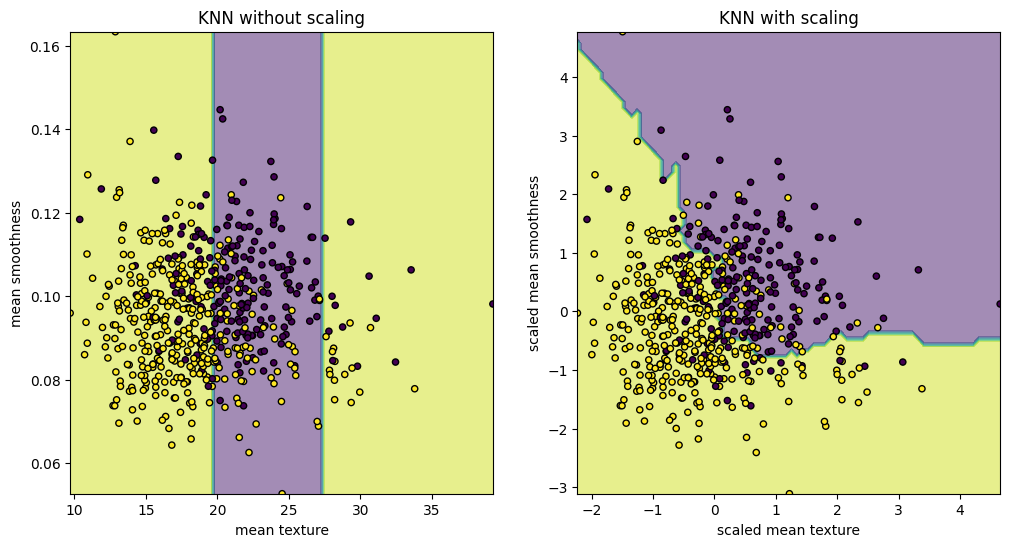

In [47]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 6))

fit_and_plot_model(X_plot, y, clf, ax1)
ax1.set_title("KNN without scaling")

fit_and_plot_model(X_plot_scaled, y, clf, ax2)
ax2.set_xlabel(f"scaled {features[0]}")
ax2.set_ylabel(f"scaled {features[1]}")
_ = ax2.set_title("KNN with scaling")

plt.show()

### 3. Investigate

Review the output.

- Was your prediction correct?
- How did scaling affect the decision boundaries?
- Look at the scale of the x-axis and y-axis in both plots. Why does the plot on the left visually emphasize vertical decision boundaries (meaning decisions rely largely on the x-axis)?

**A**1:

Yes, the prediction was correct.


**A**2:

Scaling made both features contribute equally, resulting in more balanced and realistic decision boundaries.

**A**3:

Because one feature has a much larger scale, so the model relies mostly on it, ignoring the other feature.



### 4. Modify

Modify the code below to experiment with the algorithm:

1. Change the value of `n_neighbors` (e.g., to 1 or 50) and run the cell again. What changes do you observe in the boundary map?
2. Swap `StandardScaler` with `MinMaxScaler` (from `sklearn.preprocessing`). How does it change the scaled plot?

**A**1:

- Small k (e.g., 1): complex and noisy boundaries (overfitting)
- Large k (e.g., 50): smoother boundaries (underfitting)

**A**2:

The results are similar, but values are scaled between 0 and 1 instead of centered around 0.

In [48]:
# Copy the code from the "Run" section, paste here, and modify it!

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_plot_scaled = pd.DataFrame(
    scaler.fit_transform(X_plot),
    columns=X_plot.columns
)

clf = KNeighborsClassifier(n_neighbors=30) 
clf

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",30
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


### 5. Make

Now it's your turn. Use the same dataset but select two completely different features, like `mean radius` and `mean texture`.

- Print their minimum and maximum values to evaluate their magnitude differences.
- Apply `KNeighborsClassifier` WITHOUT scaling and plot the decision boundary.
- Apply `KNeighborsClassifier` WITH scaling and plot the decision boundary.
- Does scaling make as huge of an impact here? Why or why not?

In [49]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

df = cancer.data.copy()
df["target"] = cancer.target

In [50]:
# min & max

features = ["mean radius", "mean texture"]
print(df[features].min())
print(df[features].max())

mean radius     6.981
mean texture    9.710
dtype: float64
mean radius     28.11
mean texture    39.28
dtype: float64


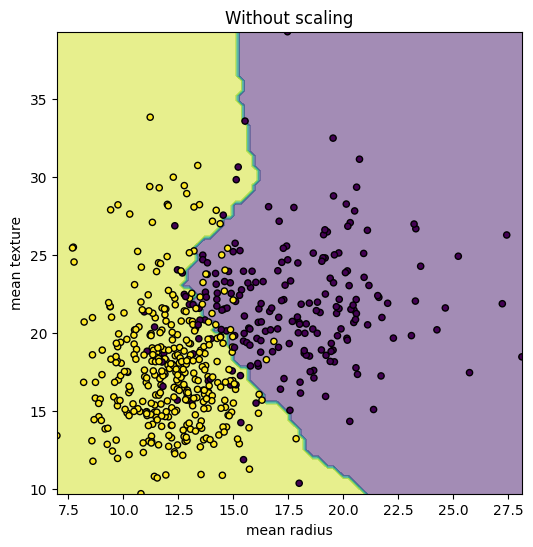

In [51]:
# Scaling Without 

X_plot = df[features]
y_plot = df["target"]

clf = KNeighborsClassifier(n_neighbors=20)

fig, ax = plt.subplots(figsize=(6,6))
fit_and_plot_model(X_plot, y_plot, clf, ax)
plt.title("Without scaling")
plt.show()

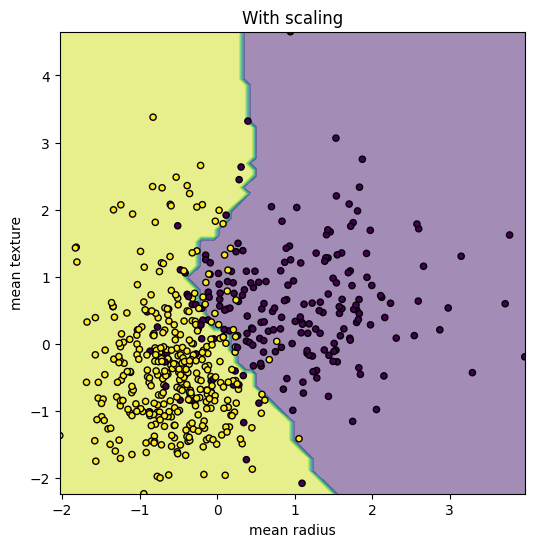

In [52]:
# Scaling With

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_plot), columns=features)

fig, ax = plt.subplots(figsize=(6,6))
fit_and_plot_model(X_scaled, y_plot, clf, ax)
plt.title("With scaling")
plt.show()

Scaling had a smaller effect because mean radius and mean texture are already on similar scales.
KNN did not heavily favor one feature over the other.